<div style="padding:24px;border-left:8px solid #C99700;background:#071B33;color:white;border-radius:8px">
<h1 style="margin:0">Lab 02 · Yield-Curve Geometry and Dynamic Factors</h1>
<p style="font-size:17px;margin-bottom:0">From high-dimensional Treasury yields to interpretable state variables—and an honest forecast benchmark.</p>
</div>

**Research question.** Do level, slope, and curvature summarize the U.S. Treasury curve, and does a dynamic Nelson–Siegel factor model forecast better than “no change”?

**Evidence.** Versioned FRED constant-maturity par yields produced by projects/yield_curve_dynamics/run_research.py. These are not zero-coupon yields; no bond-pricing claim should silently treat them as such.

## 1. Two three-factor representations

PCA solves

$$\max_{\|v_j\|=1} v_j^\top\widehat\Sigma v_j,$$

subject to orthogonality. It is statistically efficient for reconstruction but its signs and rotations are not structural.

Nelson–Siegel imposes economically shaped loadings:

$$y_t(\tau)=\beta_{1t}+\beta_{2t}\frac{1-e^{-\lambda\tau}}{\lambda\tau}
+\beta_{3t}\left(\frac{1-e^{-\lambda\tau}}{\lambda\tau}-e^{-\lambda\tau}\right)+\varepsilon_t(\tau).$$

$\beta_1$ is level-like, $\beta_2$ loads most at the short end, and $\beta_3$ is hump-shaped. With fixed $\lambda$, estimation is cross-sectional least squares.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

def find_root():
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate/'projects'/'yield_curve_dynamics'/'output'/'monthly_yields.csv').exists():
            return candidate
    raise FileNotFoundError('Run projects/yield_curve_dynamics/run_research.py first')

ROOT = find_root()
OUT = ROOT/'projects'/'yield_curve_dynamics'/'output'
yields = pd.read_csv(OUT/'monthly_yields.csv', index_col=0, parse_dates=True)
ns = pd.read_csv(OUT/'nelson_siegel_factors.csv', index_col=0, parse_dates=True)
fitted = pd.read_csv(OUT/'nelson_siegel_fitted_yields.csv', index_col=0, parse_dates=True)
maturity = {'DGS3MO':3,'DGS6MO':6,'DGS1':12,'DGS2':24,'DGS3':36,
            'DGS5':60,'DGS7':84,'DGS10':120,'DGS20':240,'DGS30':360}
plt.style.use('seaborn-v0_8-whitegrid')
NAVY, BLUE, GOLD, RED, GREEN = '#071B33', '#1676B8', '#C99700', '#C84C4C', '#26866A'
pd.options.display.float_format = '{:,.4f}'.format
print((OUT/'provenance.txt').read_text())
display(yields.describe().T[['mean','std','min','max']])

Source: FRED constant-maturity Treasury series via fredgraph CSV
URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
Series: DGS3MO, DGS6MO, DGS1, DGS2, DGS3, DGS5, DGS7, DGS10, DGS20, DGS30
Requested start: 1990-01-01
Complete monthly rows: 395
First month: 1993-10-31 00:00:00
Last month: 2026-08-31 00:00:00
Generated UTC: 2026-08-28T00:47:28.321427+00:00
Values are constant-maturity par yields in percent, not zero-coupon rates.
Monthly observations use the last available daily value.
Treasury changed its official par-curve methodology on 2021-12-06.
Synthetic fallback validates software only and cannot support market claims.



,mean,std,min,max
DGS3MO,2.5484,2.1552,0.0000,6.3800
DGS6MO,2.6583,2.1702,0.0300,6.5100
DGS1,2.7467,2.1465,0.0500,7.2000
DGS2,2.9315,2.0993,0.1100,7.6900
DGS3,3.0861,2.0194,0.1100,7.8000
DGS5,3.3948,1.8647,0.2100,7.8300
DGS7,3.6636,1.7618,0.3900,7.8400
DGS10,3.8741,1.6551,0.5500,7.9100
DGS20,4.3695,1.6202,0.9800,8.1000
DGS30,4.4002,1.4905,1.2000,7.9900


## 2. Curve history and principal-component geometry

PCA is fitted on the full panel here for **description**, not forecasting. A forecasting PCA would have to be re-estimated inside every training window.

,explained_variance,cumulative
PC1,0.9297,0.9297
PC2,0.0642,0.9939
PC3,0.0051,0.9990
PC4,0.0005,0.9995
PC5,0.0002,0.9997


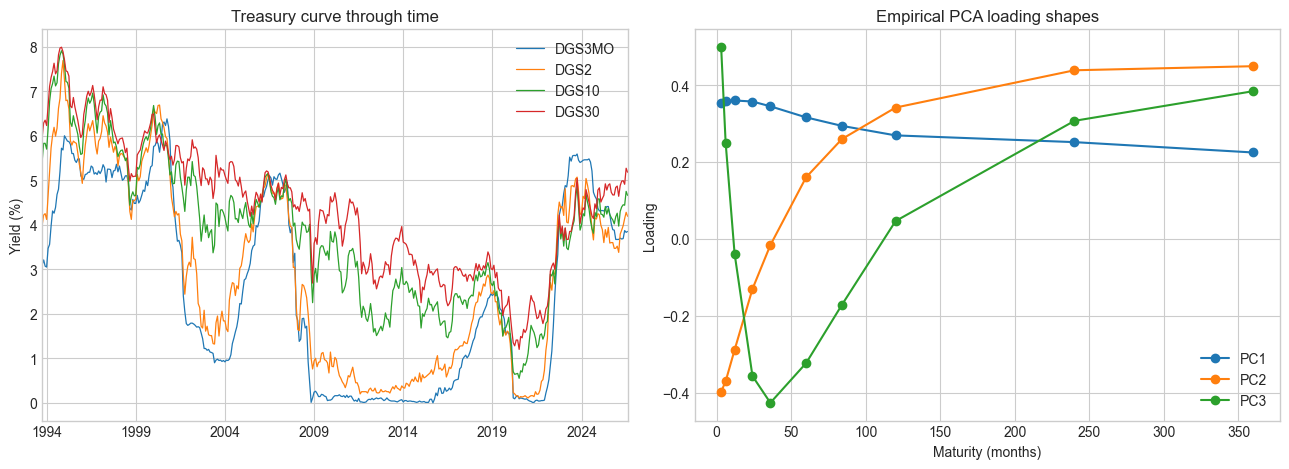

In [2]:
centered = yields - yields.mean()
u, singular, vt = np.linalg.svd(centered.to_numpy(), full_matrices=False)
loadings = pd.DataFrame(vt[:3].T, index=[maturity[c] for c in yields.columns], columns=['PC1','PC2','PC3'])
scores = pd.DataFrame(centered.to_numpy() @ vt[:3].T, index=yields.index, columns=loadings.columns)
for col in loadings:
    anchor = loadings[col].abs().idxmax()
    if loadings.loc[anchor,col] < 0:
        loadings[col] *= -1; scores[col] *= -1
explained = singular**2 / np.sum(singular**2)
display(pd.DataFrame({'explained_variance': explained[:5],
                      'cumulative': np.cumsum(explained[:5])}, index=[f'PC{i}' for i in range(1,6)]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
yields[['DGS3MO','DGS2','DGS10','DGS30']].plot(ax=axes[0], linewidth=.9)
axes[0].set(title='Treasury curve through time', ylabel='Yield (%)', xlabel='')
loadings.plot(ax=axes[1], marker='o')
axes[1].set(title='Empirical PCA loading shapes', xlabel='Maturity (months)', ylabel='Loading')
plt.tight_layout(); plt.show()

## 3. Interpretability versus reconstruction

PCA factors are orthogonal by construction. Nelson–Siegel factors are shaped for interpretation and need not be orthogonal. Comparing standardized factor correlations shows whether the economic labels align with the empirical directions; reconstruction residuals reveal the cost of the restriction.

,level,slope,curvature
PC1,0.830169,0.423783,0.663434
PC2,0.538830,-0.901559,-0.323810
PC3,0.143083,0.087050,-0.674234


,NS_RMSE_pct_points,mean_abs_error
DGS3MO,0.1117,0.0930
DGS6MO,0.0543,0.0385
DGS1,0.1123,0.0912
DGS2,0.0906,0.0744
DGS3,0.0353,0.0263
DGS5,0.1010,0.0837
DGS7,0.1041,0.0849
DGS10,0.1089,0.0965
DGS20,0.1385,0.1200
DGS30,0.1091,0.0805


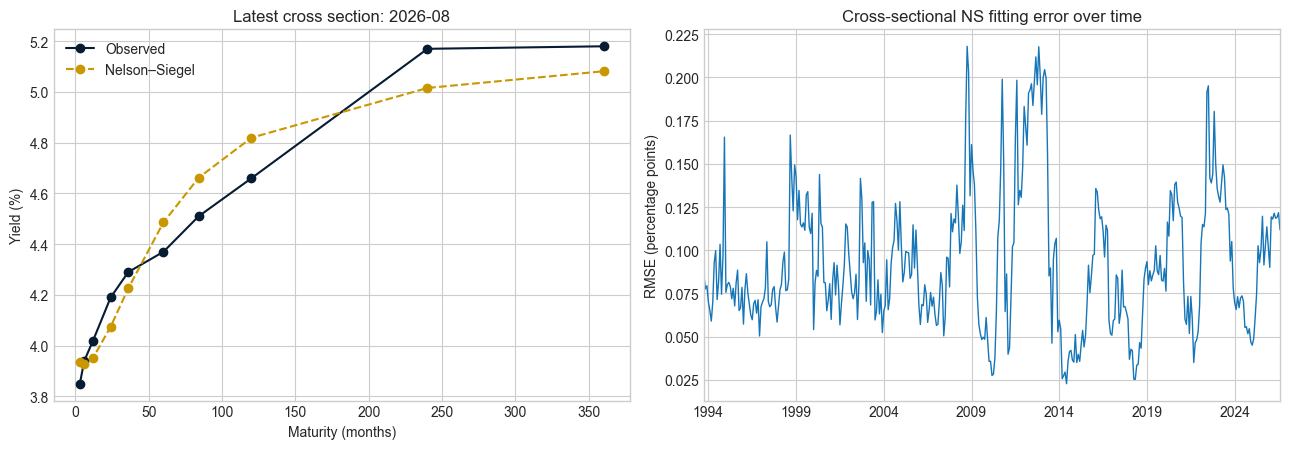

In [3]:
joined = scores.join(ns[['level','slope','curvature']]).dropna()
factor_map = joined.corr().loc[['PC1','PC2','PC3'], ['level','slope','curvature']]
residual = yields - fitted
rmse_by_date = np.sqrt((residual**2).mean(axis=1))
rmse_by_maturity = np.sqrt((residual**2).mean(axis=0))
display(factor_map.style.background_gradient(cmap='RdBu', vmin=-1, vmax=1))
display(pd.DataFrame({'NS_RMSE_pct_points': rmse_by_maturity,
                      'mean_abs_error': residual.abs().mean()}))

latest = yields.index[-1]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].plot(list(maturity.values()), yields.loc[latest], 'o-', color=NAVY, label='Observed')
axes[0].plot(list(maturity.values()), fitted.loc[latest], 'o--', color=GOLD, label='Nelson–Siegel')
axes[0].set(title=f'Latest cross section: {latest:%Y-%m}', xlabel='Maturity (months)', ylabel='Yield (%)')
axes[0].legend(frameon=False)
rmse_by_date.plot(ax=axes[1], color=BLUE, linewidth=1)
axes[1].set(title='Cross-sectional NS fitting error over time', xlabel='', ylabel='RMSE (percentage points)')
plt.tight_layout(); plt.show()

## 4. Dynamic factors versus the difficult benchmark

The project estimates a recursive VAR(1) on the three Nelson–Siegel factors. At forecast origin $t$ it uses only data available through $t$. The benchmark is the random walk $\widehat y_{t+1|t}(\tau)=y_t(\tau)$, historically difficult to beat for yields.

For each maturity we test the average loss differential

$$d_t=e^2_{NS,t}-e^2_{RW,t}.$$

Negative values favor Nelson–Siegel. HAC standard errors allow serial dependence in $d_t$; this is a diagnostic, not a claim that ten correlated maturity tests are independent.

,months,RMSE_NS,RMSE_RW,relative_RMSE,mean_loss_diff,HAC_t,HAC_p
series,,,,,,,
DGS3MO,3,0.2066,0.2059,1.0034,0.0003,0.0372,0.9704
DGS6MO,6,0.2020,0.1976,1.0225,0.0018,0.3634,0.7163
DGS1,12,0.2417,0.1997,1.2102,0.0185,2.4948,0.0126
DGS2,24,0.2639,0.2295,1.1503,0.0170,4.5010,0.0000
DGS3,36,0.2562,0.2429,1.0549,0.0066,2.2729,0.0230
DGS5,60,0.2698,0.2533,1.0654,0.0087,2.0947,0.0362
DGS7,84,0.2705,0.2536,1.0664,0.0088,1.9357,0.0529
DGS10,120,0.2549,0.2460,1.0361,0.0045,1.2859,0.1985
DGS20,240,0.2705,0.2353,1.1494,0.0178,3.7365,0.0002


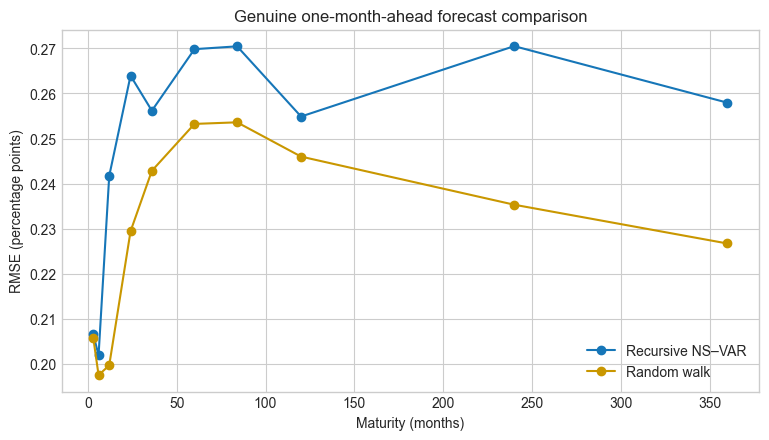

NS–VAR has lower RMSE at 0 of 10 maturities.


In [4]:
ns_fc = pd.read_csv(OUT/'recursive_ns_var_forecasts.csv', index_col=0, parse_dates=True)
rw_fc = pd.read_csv(OUT/'random_walk_forecasts.csv', index_col=0, parse_dates=True)
actual = yields.reindex(ns_fc.index)
records = []
for col in yields.columns:
    e_ns = ns_fc[col] - actual[col]
    e_rw = rw_fc[col] - actual[col]
    d = (e_ns**2-e_rw**2).dropna()
    result = sm.OLS(d.to_numpy(), np.ones((len(d),1))).fit(cov_type='HAC', cov_kwds={'maxlags':6})
    records.append({'series':col, 'months':maturity[col],
                    'RMSE_NS':np.sqrt(np.mean(e_ns**2)), 'RMSE_RW':np.sqrt(np.mean(e_rw**2)),
                    'relative_RMSE':np.sqrt(np.mean(e_ns**2))/np.sqrt(np.mean(e_rw**2)),
                    'mean_loss_diff':d.mean(), 'HAC_t':result.tvalues[0], 'HAC_p':result.pvalues[0]})
forecast = pd.DataFrame(records).set_index('series').sort_values('months')
display(forecast)

fig, ax = plt.subplots(figsize=(9, 4.7))
ax.plot(forecast.months, forecast.RMSE_NS, 'o-', label='Recursive NS–VAR', color=BLUE)
ax.plot(forecast.months, forecast.RMSE_RW, 'o-', label='Random walk', color=GOLD)
ax.set(xlabel='Maturity (months)', ylabel='RMSE (percentage points)', title='Genuine one-month-ahead forecast comparison')
ax.legend(frameon=False); plt.show()
wins = int((forecast.relative_RMSE < 1).sum())
print(f'NS–VAR has lower RMSE at {wins} of {len(forecast)} maturities.')

## 5. Factor shocks as risk scenarios

A factor model becomes financially useful when shocks map back into yields. Below, a one-standard-deviation historical shock to each Nelson–Siegel factor is translated into a maturity-by-maturity curve move. This is a statistical scenario, not a regulatory stress and not a causal intervention.

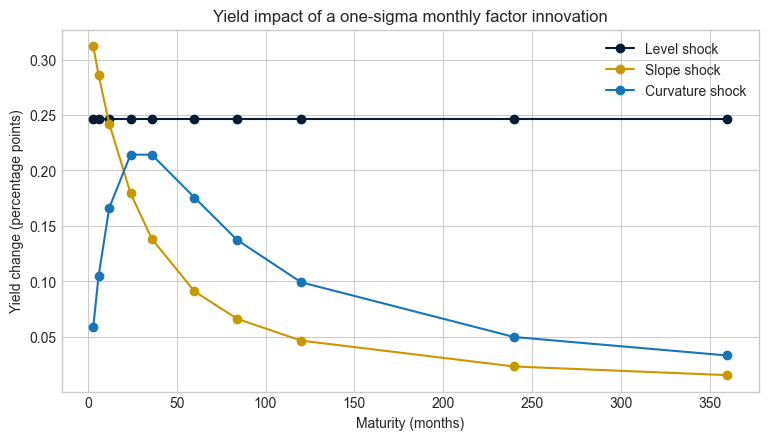

,Level shock,Slope shock,Curvature shock
3.0000,0.2464,0.3121,0.0591
6.0000,0.2464,0.2860,0.1049
12.0000,0.2464,0.2423,0.1663
24.0000,0.2464,0.1795,0.2143
36.0000,0.2464,0.1384,0.2142
60.0000,0.2464,0.0910,0.1756
84.0000,0.2464,0.0663,0.1374
120.0000,0.2464,0.0467,0.0993
240.0000,0.2464,0.0234,0.0499
360.0000,0.2464,0.0156,0.0333


In [5]:
tau = np.array(list(maturity.values()), dtype=float)
lam = 0.0609
x = lam*tau
L1 = np.ones_like(tau)
L2 = (1-np.exp(-x))/x
L3 = L2-np.exp(-x)
L = np.column_stack([L1,L2,L3])
shock_sd = ns[['level','slope','curvature']].diff().std().to_numpy()
scenarios = pd.DataFrame(L*shock_sd, index=tau,
                         columns=['Level shock','Slope shock','Curvature shock'])
ax = scenarios.plot(figsize=(9,4.7), marker='o', color=[NAVY,GOLD,BLUE])
ax.set(title='Yield impact of a one-sigma monthly factor innovation', xlabel='Maturity (months)', ylabel='Yield change (percentage points)')
plt.show()
display(scenarios)

## 6. Research conclusion and model-risk register

- Three PCs explain nearly all cross-sectional variation, but variance explained is not forecast performance and does not establish economic causality.
- Nelson–Siegel trades a small reconstruction cost for stable, interpretable loading shapes.
- The random walk is the relevant forecasting hurdle. A sophisticated factor model can describe the curve beautifully without consistently forecasting it better.
- HAC tests partly address dependent loss differentials; they do not resolve data snooping across maturities or model variants.

> **Boundary of the evidence.** Constant-maturity Treasury series are par-yield estimates with methodology changes. Pricing, no-arbitrage term-premium decomposition, and zero-coupon duration require a bootstrapped discount curve and additional assumptions.

### Extensions

1. Re-estimate $\lambda$ recursively and quantify parameter instability.
2. Bootstrap zero-coupon curves and compare yield-factor shocks with key-rate DV01.
3. Add affine no-arbitrage restrictions and separate expected short rates from term premia.
4. Use a Giacomini–White conditional predictive-ability test across policy regimes.